In [1]:
import pandas as pd
import numpy as np
import os
import cv2

In [3]:
data =[]
labels=[]
path =r'C:\Users\ACER\Downloads\facemask\data\with_mask'
for img in os.listdir(path):
  img_path=os.path.join(path,img)
  img=cv2.imread(img_path)
  img=cv2.resize(img,(224,224))

  data.append(img)
  labels.append(0)

path =r'C:\Users\ACER\Downloads\facemask\data\without_mask'
for img in os.listdir(path):
  img_path=os.path.join(path,img)
  img=cv2.imread(img_path)
  img=cv2.resize(img,(224,224))

  data.append(img)
  labels.append(0)

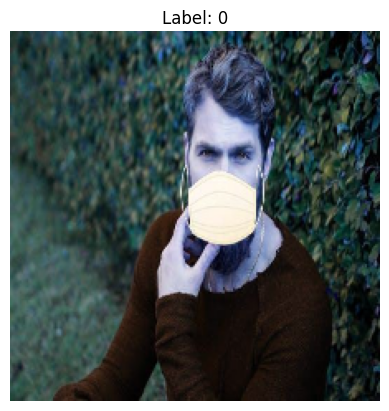

In [5]:
import matplotlib.pyplot as plt

plt.imshow(data[0])
plt.title("Label: " + str(labels[0]))
plt.axis('off')
plt.show()

In [6]:
data=np.array(data)
labels=np.array(labels)

In [7]:
data.shape

(5364, 224, 224, 3)

In [8]:
data=data/255

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(data,labels,test_size=0.2,random_state=42)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense

In [32]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

In [ ]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

In [ ]:
print(set(labels))